---

# CHAPTER 2: DATA CLEANING AND IMPUTATION

---

<br><br>

---

## Lesson 1: Addressing Missing Data

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Dataframe of the lesson
df = pd.read_csv('Resources/ds_salaries_clean.csv')
df.head()

,Working_Year,Designation,Experience,Employment_Status,Employee_Location,Company_Size,Remote_Working_Ratio,Salary_USD
0,2020,Data Scientist,Mid,FT,DE,L,0,76227.0
1,2020,Machine Learning Scientist,Senior,FT,JP,S,0,248257.0
2,2020,Big Data Engineer,Senior,FT,GB,M,50,104100.0
3,2020,Product Data Analyst,Mid,FT,HN,S,0,19097.0
4,2020,Machine Learning Engineer,Senior,FT,US,L,50,143225.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Working_Year          607 non-null    int64  
 1   Designation           607 non-null    object 
 2   Experience            607 non-null    object 
 3   Employment_Status     607 non-null    object 
 4   Employee_Location     607 non-null    object 
 5   Company_Size          607 non-null    object 
 6   Remote_Working_Ratio  607 non-null    int64  
 7   Salary_USD            607 non-null    float64
dtypes: float64(1), int64(2), object(5)
memory usage: 38.1+ KB


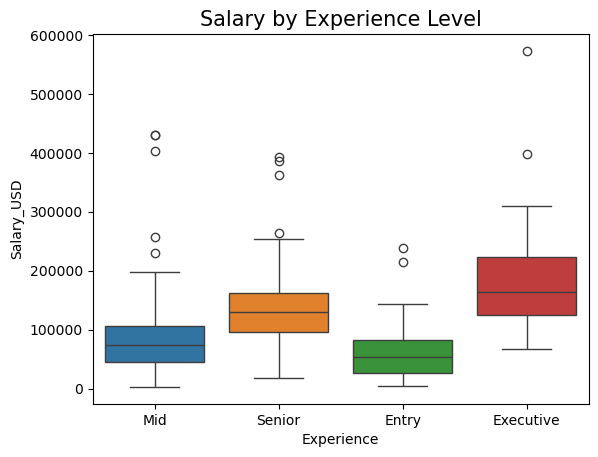

In [4]:
sns.boxplot(data=df, x='Experience', y='Salary_USD', hue='Experience')

plt.title('Salary by Experience Level', fontsize=15)
plt.show()

<br><br>

---

### Checking for Missing Values

In [5]:
df.isna().sum()

Working_Year            0
Designation             0
Experience              0
Employment_Status       0
Employee_Location       0
Company_Size            0
Remote_Working_Ratio    0
Salary_USD              0
dtype: int64

<br><br>

---

### Strategies for Addressing Missing Data

- Drop Missing Values if the total missing values on the dataset represent 5% of less.

If we have more missing values:

- Impute using the "Mean", "Median", or "Mode", depending on the distribution and the context.

- Impute by "Sub-Groups". If there is another column highly correlated with the one we want to impute we can fill missing values considering the behaviour of the correlated column. For example: If we want to fill missing values on a "Salary" Column, the column of "Experience" might be helpful.

In [6]:
salaries = pd.read_csv('Resources/ds_salaries_ (missing).csv')
salaries

,Working_Year,Designation,Experience,Employment_Status,Employee_Location,Company_Size,Remote_Working_Ratio,Salary_USD
0,2020.0,Data Scientist,Mid,FT,DE,L,0.0,76227.0
1,2020.0,Machine Learning Scientist,Senior,FT,JP,S,0.0,248257.0
2,2020.0,Big Data Engineer,Senior,FT,GB,M,50.0,104100.0
3,2020.0,Product Data Analyst,Mid,FT,HN,S,0.0,19097.0
4,2020.0,Machine Learning Engineer,Senior,FT,US,NaN,50.0,NaN
...,...,...,...,...,...,...,...,...
602,2022.0,Data Engineer,Senior,FT,US,M,100.0,147044.0
603,2022.0,Data Engineer,Senior,FT,US,M,100.0,120309.0
604,2022.0,Data Analyst,Senior,FT,US,M,0.0,123174.0
605,2022.0,Data Analyst,NaN,FT,US,M,100.0,143225.0


In [7]:
salaries.isna().sum()

Working_Year            12
Designation             27
Experience              33
Employment_Status       31
Employee_Location       28
Company_Size            39
Remote_Working_Ratio    24
Salary_USD              58
dtype: int64

<br><br>

---

### Calculate the Threshold of Missing Values

In [8]:
threshold = int(len(salaries) * 0.05)
threshold

30

<br><br>

---

### Boolean Filtering using the Threshold

In [9]:
# Let's see how the 'threshold' find missing values less than 5%
salaries.isna().sum() <= threshold

Working_Year             True
Designation              True
Experience              False
Employment_Status       False
Employee_Location        True
Company_Size            False
Remote_Working_Ratio     True
Salary_USD              False
dtype: bool

In [10]:

cols_to_drop = list(salaries.columns[salaries.isna().sum() <= threshold])
cols_to_drop

['Working_Year', 'Designation', 'Employee_Location', 'Remote_Working_Ratio']

In [11]:
salaries.dropna(subset=cols_to_drop, inplace=True)
salaries

,Working_Year,Designation,Experience,Employment_Status,Employee_Location,Company_Size,Remote_Working_Ratio,Salary_USD
0,2020.0,Data Scientist,Mid,FT,DE,L,0.0,76227.0
1,2020.0,Machine Learning Scientist,Senior,FT,JP,S,0.0,248257.0
2,2020.0,Big Data Engineer,Senior,FT,GB,M,50.0,104100.0
3,2020.0,Product Data Analyst,Mid,FT,HN,S,0.0,19097.0
4,2020.0,Machine Learning Engineer,Senior,FT,US,NaN,50.0,NaN
...,...,...,...,...,...,...,...,...
602,2022.0,Data Engineer,Senior,FT,US,M,100.0,147044.0
603,2022.0,Data Engineer,Senior,FT,US,M,100.0,120309.0
604,2022.0,Data Analyst,Senior,FT,US,M,0.0,123174.0
605,2022.0,Data Analyst,NaN,FT,US,M,100.0,143225.0


<br><br>

---

### Imputing a Summary Statistic

In [12]:
salaries.isna().sum()

Working_Year             0
Designation              0
Experience              29
Employment_Status       27
Employee_Location        0
Company_Size            34
Remote_Working_Ratio     0
Salary_USD              46
dtype: int64

<br><br>

In [13]:
# We then filter for the remaining columns with missing values, giving us four columns.
cols_with_missing_values = list(salaries.columns[salaries.isna().sum() > 0])
cols_with_missing_values

['Experience', 'Employment_Status', 'Company_Size', 'Salary_USD']

<br><br>

In [14]:
# To impute the 'mode' for the first three columns, we loop through them and call fillna method
# and fill missing values with the mode
for col in cols_with_missing_values[:-1]:
    salaries[col] = salaries[col].fillna(salaries[col].mode()[0])

salaries.isna().sum()

Working_Year             0
Designation              0
Experience               0
Employment_Status        0
Employee_Location        0
Company_Size             0
Remote_Working_Ratio     0
Salary_USD              46
dtype: int64

<br><br>

---

### Imputing by Sub-Group

In [15]:
# Lets grab the indexes of all rows that have a NAN value on 'Salary_USD'
salaries_nan_index = salaries[salaries['Salary_USD'].isna() == True].index
salaries_nan_index

Index([  4,  15,  55,  67,  95, 109, 144, 157, 170, 196, 241, 259, 277, 286,
       301, 311, 316, 328, 342, 354, 355, 367, 377, 385, 393, 400, 404, 411,
       423, 436, 445, 459, 463, 468, 479, 489, 491, 504, 512, 529, 532, 551,
       555, 581, 590, 600],
      dtype='int64')

In [16]:
salaries.loc[salaries_nan_index].head()

,Working_Year,Designation,Experience,Employment_Status,Employee_Location,Company_Size,Remote_Working_Ratio,Salary_USD
4,2020.0,Machine Learning Engineer,Senior,FT,US,M,50.0,NaN
15,2020.0,Data Analyst,Senior,FT,PK,L,50.0,NaN
55,2020.0,Principal Data Scientist,Senior,FT,DE,M,100.0,NaN
67,2020.0,Data Science Manager,Senior,FT,US,M,100.0,NaN
95,2021.0,Cloud Data Engineer,Mid,FT,SG,L,50.0,NaN


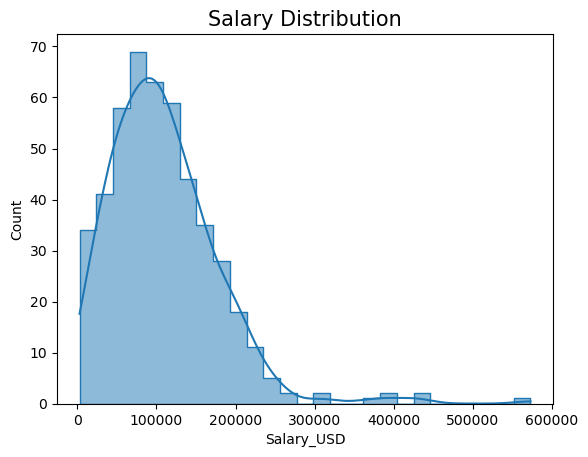

In [17]:
# It's time to see the distribution of the data on "Salary_USD"
sns.histplot(data=salaries, x='Salary_USD', element='step', kde=True)
plt.title('Salary Distribution', fontsize=15)
plt.show()

<br><br>

---

We'll impute median salary by "Experience" level. By grouping "Salaries" by "Experience" and calculating the "Median". Since the data is skewed to the rigth, and the mean is not a good option for filling missing values.

We use the ".to_dict()" method, storing the grouped data as a dictionary. 

Printing the dictionary returns the median salary for each experience level, with executives earning the big bucks!

---

<br><br>

In [18]:
# Lets take the "Median" of the "Experience" values
salaries.groupby('Experience')['Salary_USD'].median()

# Create a Dictionary with the key as 'Experience' and "Median" of "Salary_USD"
salaries_dict = salaries.groupby('Experience')['Salary_USD'].median().to_dict()
salaries_dict

{'Entry': 55414.0, 'Executive': 177589.0, 'Mid': 73482.0, 'Senior': 126038.0}

---

...now it's time to impute by sub-group

In [19]:
# Imputing by Sub-Group using our new dictionary "salaries_dict"

salaries['Salary_USD'] = salaries['Salary_USD'].fillna(salaries['Experience'].map(salaries_dict))
salaries.isna().sum()

Working_Year            0
Designation             0
Experience              0
Employment_Status       0
Employee_Location       0
Company_Size            0
Remote_Working_Ratio    0
Salary_USD              0
dtype: int64

In [21]:
# Now we'll confirm that the missing values were filled with the median values according to "Experience" column
salaries.loc[salaries_nan_index].sample(10)

,Working_Year,Designation,Experience,Employment_Status,Employee_Location,Company_Size,Remote_Working_Ratio,Salary_USD
15,2020.0,Data Analyst,Senior,FT,PK,L,50.0,126038.0
95,2021.0,Cloud Data Engineer,Mid,FT,SG,L,50.0,73482.0
301,2022.0,Data Scientist,Senior,FT,GB,M,0.0,126038.0
555,2022.0,Data Engineer,Senior,FT,US,M,100.0,126038.0
600,2022.0,Data Analyst,Entry,FT,CA,M,0.0,55414.0
551,2022.0,Data Scientist,Senior,FT,US,L,0.0,126038.0
385,2022.0,Data Engineer,Senior,FT,US,M,100.0,126038.0
241,2021.0,Data Analyst,Mid,FT,US,L,100.0,73482.0
529,2022.0,Data Analyst,Senior,FT,US,M,100.0,126038.0
590,2022.0,Data Architect,Senior,FT,US,M,100.0,126038.0


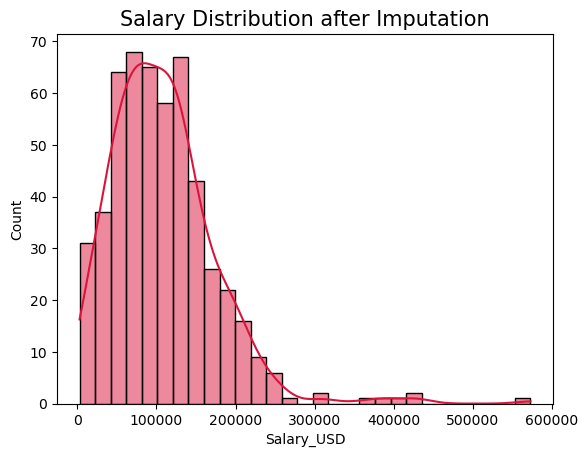

In [26]:
# It's time to see the NEW distribution of the data on "Salary_USD" after Imputation
sns.histplot(data=salaries, x='Salary_USD', element='bars', kde=True, color='crimson')
plt.title('Salary Distribution after Imputation', fontsize=15)
plt.show()